<a href="https://colab.research.google.com/github/AliceNanL/BA820-project/blob/M2_Anna-Wei_Childcare-Cost/BA820_AnnaWei_M2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **B1 Team 11**
## M2 — Anna Wei

# **Data Preparation**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

childcare_costs = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/BA820/childcare_costs.csv'
)

counties = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/BA820/counties.csv'
)

In [5]:
print(childcare_costs.head())
print(counties.head())

   county_fips_code  study_year  unr_16  funr_16  munr_16  unr_20to64  \
0              1001        2008    5.42     4.41     6.32         4.6   
1              1001        2009    5.93     5.72     6.11         4.8   
2              1001        2010    6.21     5.57     6.78         5.1   
3              1001        2011    7.55     8.13     7.03         6.2   
4              1001        2012    8.60     8.88     8.29         6.7   

   funr_20to64  munr_20to64  flfpr_20to64  flfpr_20to64_under6  ...  memp_p  \
0          3.5          5.6          68.9                 66.9  ...   21.55   
1          4.6          5.0          70.8                 63.7  ...   21.96   
2          4.6          5.6          71.3                 67.0  ...   21.28   
3          6.3          6.1          70.2                 66.5  ...   22.80   
4          6.4          7.0          70.6                 67.1  ...   22.88   

   femp_p   mcsa  mfccsa  mc_infant  mc_toddler  mc_preschool  mfcc_infant  \
0    4.0

In [6]:
childcare_costs['county_fips_code'] = childcare_costs['county_fips_code'].astype(str)
counties['county_fips_code'] = counties['county_fips_code'].astype(str)

merged_df = pd.merge(
    childcare_costs,
    counties,
    on='county_fips_code',
    how='inner'
)

##**Merged Data**

In [7]:
merged_df['_merge'] = pd.merge(
    childcare_costs,
    counties,
    on='county_fips_code',
    how='inner',
    indicator=True
)['_merge']

merged_df['_merge'].value_counts()

,count
_merge,
both,34567
left_only,0
right_only,0


In [8]:
merged_df.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/BA820/childcare_cost_with_counties.csv',
    index=False
)

In [9]:
merged_df.shape

(34567, 65)

In [10]:
merged_df.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation,_merge
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL,both
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL,both
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL,both
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL,both
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL,both


In [11]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 65 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   county_fips_code           34567 non-null  object  
 1   study_year                 34567 non-null  int64   
 2   unr_16                     34567 non-null  float64 
 3   funr_16                    34567 non-null  float64 
 4   munr_16                    34567 non-null  float64 
 5   unr_20to64                 34567 non-null  float64 
 6   funr_20to64                34567 non-null  float64 
 7   munr_20to64                34567 non-null  float64 
 8   flfpr_20to64               34567 non-null  float64 
 9   flfpr_20to64_under6        34567 non-null  float64 
 10  flfpr_20to64_6to17         34567 non-null  float64 
 11  flfpr_20to64_under6_6to17  34567 non-null  float64 
 12  mlfpr_20to64               34567 non-null  float64 
 13  pr_f                       3456

We can see that the attributes: mcsa, mfccsa, mc_infant, mc_toddler, mc_preschool, mfcc_infant, mfcc_toddler, mfcc_preschool all have some missing values.

## **Data Cleaning**

In [12]:
merged_df.isnull().sum()

,0
county_fips_code,0
study_year,0
unr_16,0
funr_16,0
munr_16,0
...,...
mfcc_preschool,11184
county_name,0
state_name,0
state_abbreviation,0


In [9]:
import numpy as np

childcare_cols = [
    "mcsa", "mfccsa",
    "mc_infant", "mc_toddler", "mc_preschool",
    "mfcc_infant", "mfcc_toddler", "mfcc_preschool"
]

merged_df[childcare_cols] = (
    merged_df[childcare_cols]
    .apply(pd.to_numeric, errors="coerce")
)

The code above standarizes the missing values and preserves them as NaN instead of imputing and potentially introducing bias.

In [14]:
merged_df.describe()

,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,flfpr_20to64_6to17,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
count,34567.000000,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,34567.000000,34567.000000,23593.000000,23383.000000,23593.000000,23593.000000,23593.000000,23383.000000,23383.000000,23383.000000
mean,2012.999711,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,78.824106,...,23.456238,7.634403,101.234253,92.523582,146.051770,130.482768,122.232852,113.421657,106.759749,104.189510
std,3.162232,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,8.529813,...,7.956927,4.501044,34.552888,27.669904,53.698566,43.775370,38.538323,32.819372,29.982431,28.961701
min,2008.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,0.000000,...,0.000000,0.000000,18.980000,22.000000,27.730000,21.540000,21.540000,43.080000,43.080000,40.030000
25%,2010.000000,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,74.400000,...,17.610000,4.410000,78.650000,75.000000,108.750000,100.000000,95.880000,90.000000,85.085000,84.255000
50%,2013.000000,7.050000,6.59000,7.390000,6.500000,6.000000,6.800000,70.600000,69.600000,79.450000,...,23.400000,6.630000,96.530000,88.180000,134.500000,120.990000,113.990000,106.000000,100.250000,99.650000
75%,2016.000000,9.350000,8.88000,9.920000,8.700000,8.250000,9.200000,75.500000,76.100000,84.225000,...,28.930000,9.920000,119.380000,107.500000,166.330000,148.710000,139.300000,129.315000,124.950000,120.200000
max,2018.000000,36.110000,38.24000,39.740000,33.900000,44.500000,45.500000,100.000000,100.000000,100.000000,...,87.500000,66.480000,375.400000,308.000000,470.000000,419.000000,385.000000,430.940000,376.320000,331.340000


# **Updated EDA**

Reframing the focus of the Demographics and Social Equity domain, I've decided to update the initial EDA by looking at the distribution and the availability of existing centered-based and family childcare areas.

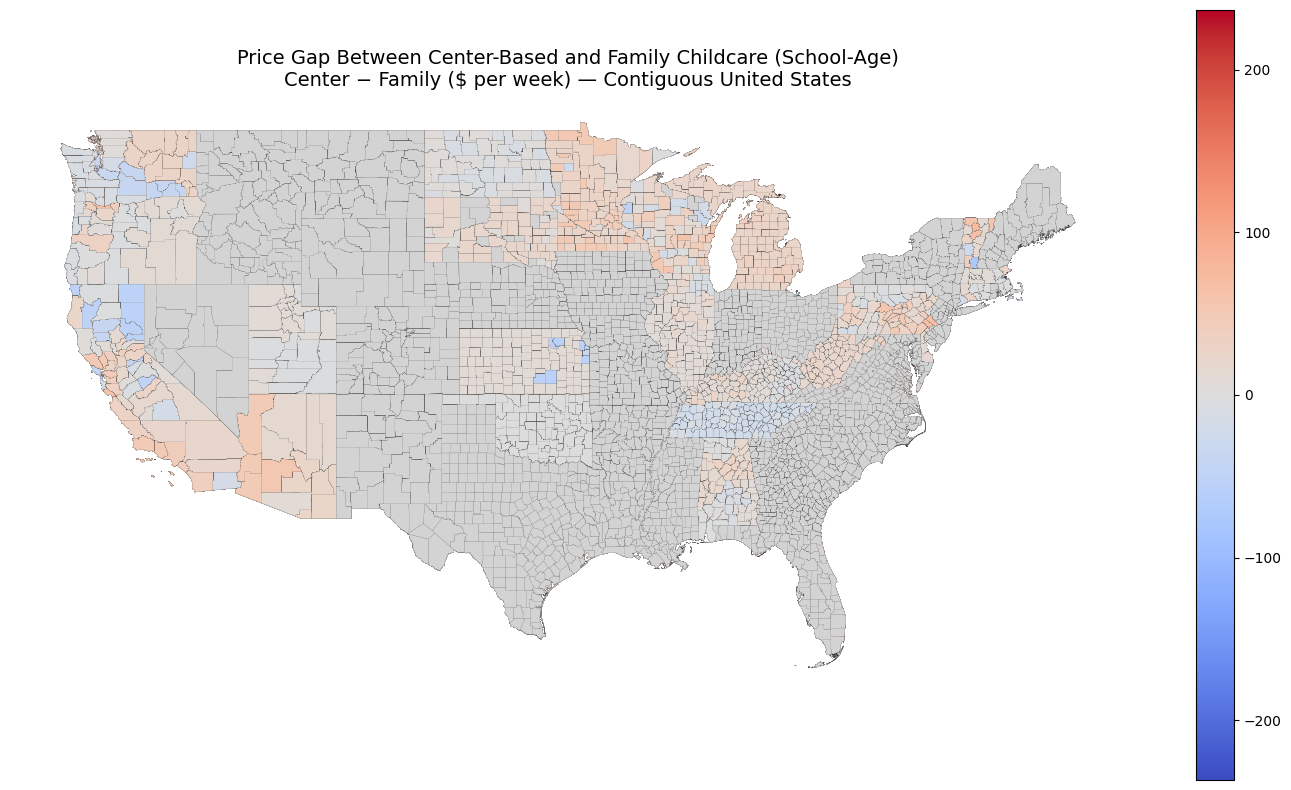

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

merged_df["price_gap_school_age"] = merged_df["mcsa"] - merged_df["mfccsa"]


merged_df["county_fips_code"] = (
    merged_df["county_fips_code"].astype(str).str.zfill(5)
)

counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip"
)
counties["GEOID"] = counties["GEOID"].astype(str)

map_df = counties.merge(
    merged_df[["county_fips_code", "price_gap_school_age"]],
    left_on="GEOID",
    right_on="county_fips_code",
    how="left"
)

contiguous = map_df[
    ~map_df["STATEFP"].isin(["02", "15", "60", "66", "69", "72", "78"])
]


vmax = max(
    abs(contiguous["price_gap_school_age"].min(skipna=True)),
    abs(contiguous["price_gap_school_age"].max(skipna=True))
)

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

contiguous.plot(
    column="price_gap_school_age",
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax,
    linewidth=0.05,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title(
    "Price Gap Between Center-Based and Family Childcare (School-Age)\nCenter − Family ($ per week) — Contiguous United States",
    fontsize=14
)
ax.axis("off")

plt.show()

As shown in the map above, areas highlighted in red indicate counties where center-based childcare is more expensive than family childcare. The larger the red value, the higher the weekly price premium for center-based care. This pattern suggests that center-based care may pose a greater financial barrier for families in these areas. In contrast, blue areas indicate counties where center-based care is relatively cheaper compared to family childcare. Overall, the map reflects relative price differences rather than the availability or prevalence of childcare providers.

## **Racial Demographics**

<Figure size 800x600 with 0 Axes>

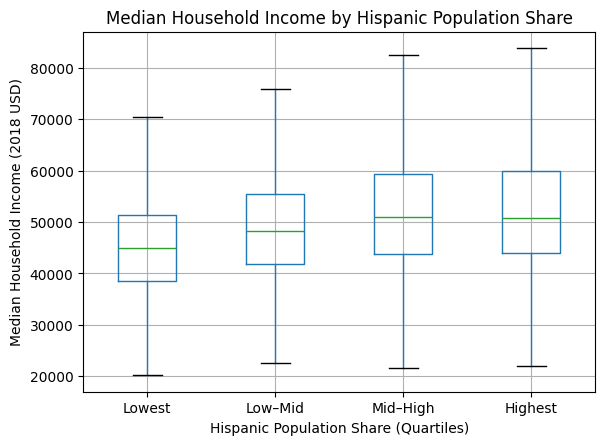

In [47]:
import matplotlib.pyplot as plt

eda_df = merged_df[
["hispanic", "mhi_2018"]
].dropna()

eda_df["hispanic_quartile"] = pd.qcut(
    eda_df["hispanic"],
    q=4,
    labels=["Lowest", "Low–Mid", "Mid–High", "Highest"]
)


plt.figure(figsize=(8, 6))

eda_df.boxplot(
    column="mhi_2018",
    by="hispanic_quartile",
    showfliers=False
)

plt.xlabel("Hispanic Population Share (Quartiles)")
plt.ylabel("Median Household Income (2018 USD)")
plt.title("Median Household Income by Hispanic Population Share")
plt.suptitle("")

plt.show()

<Figure size 800x600 with 0 Axes>

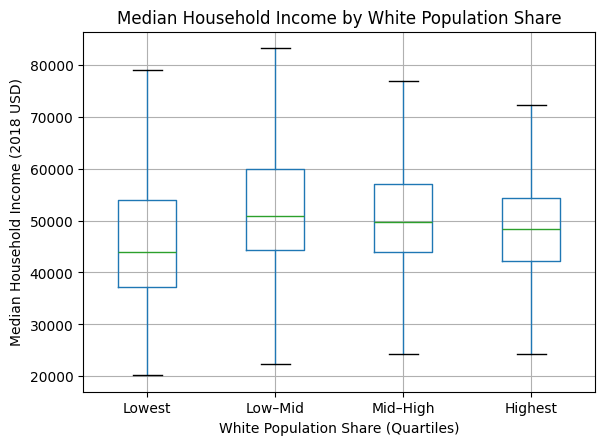

In [46]:
import matplotlib.pyplot as plt

eda_df = merged_df[
["one_race_w", "mhi_2018"]
].dropna()

eda_df["white_quartile"] = pd.qcut(
    eda_df["one_race_w"],
    q=4,
    labels=["Lowest", "Low–Mid", "Mid–High", "Highest"]
)


plt.figure(figsize=(8, 6))

eda_df.boxplot(
    column="mhi_2018",
    by="white_quartile",
    showfliers=False
)

plt.xlabel("White Population Share (Quartiles)")
plt.ylabel("Median Household Income (2018 USD)")
plt.title("Median Household Income by White Population Share")
plt.suptitle("")

plt.show()

<Figure size 800x600 with 0 Axes>

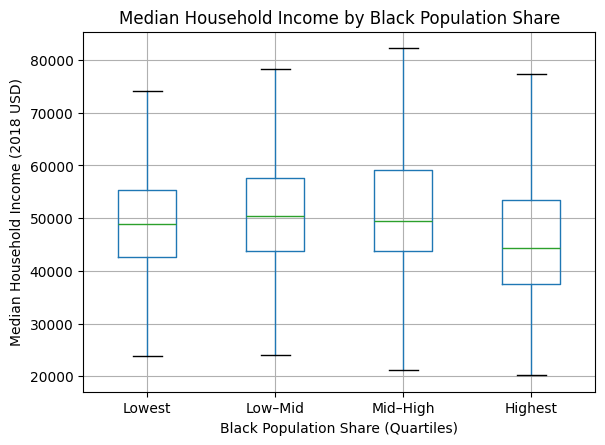

In [45]:
import matplotlib.pyplot as plt

eda_df = merged_df[
["one_race_b", "mhi_2018"]
].dropna()

eda_df["black_quartile"] = pd.qcut(
    eda_df["one_race_b"],
    q=4,
    labels=["Lowest", "Low–Mid", "Mid–High", "Highest"]
)


plt.figure(figsize=(8, 6))

eda_df.boxplot(
    column="mhi_2018",
    by="black_quartile",
    showfliers=False
)

plt.xlabel("Black Population Share (Quartiles)")
plt.ylabel("Median Household Income (2018 USD)")
plt.title("Median Household Income by Black Population Share")
plt.suptitle("")

plt.show()

<Figure size 800x600 with 0 Axes>

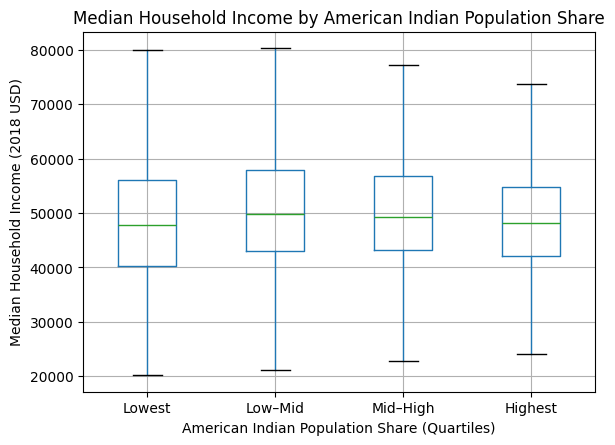

In [44]:
import matplotlib.pyplot as plt

eda_df = merged_df[
["one_race_i", "mhi_2018"]
].dropna()

eda_df["american_indian_quartile"] = pd.qcut(
    eda_df["one_race_i"],
    q=4,
    labels=["Lowest", "Low–Mid", "Mid–High", "Highest"]
)


plt.figure(figsize=(8, 6))

eda_df.boxplot(
    column="mhi_2018",
    by="american_indian_quartile",
    showfliers=False
)

plt.xlabel("American Indian Population Share (Quartiles)")
plt.ylabel("Median Household Income (2018 USD)")
plt.title("Median Household Income by American Indian Population Share")
plt.suptitle("")

plt.show()

<Figure size 800x600 with 0 Axes>

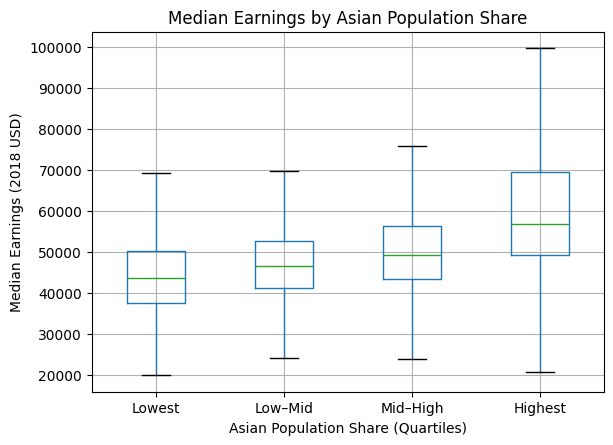

In [42]:
import matplotlib.pyplot as plt

eda_df = merged_df[
["one_race_a", "mhi_2018"]
].dropna()

eda_df["asian_quartile"] = pd.qcut(
    eda_df["one_race_a"],
    q=4,
    labels=["Lowest", "Low–Mid", "Mid–High", "Highest"]
)


plt.figure(figsize=(8, 6))

eda_df.boxplot(
    column="mhi_2018",
    by="asian_quartile",
    showfliers=False
)

plt.xlabel("Asian Population Share (Quartiles)")
plt.ylabel("Median Earnings (2018 USD)")
plt.title("Median Earnings by Asian Population Share")
plt.suptitle("")

plt.show()

The distrubtion of median income in terms of race has a fairly even disturbition overall, with Asian popluation reporting slightly higher earnings of over 50000 (outlier).

## **Pair Plot**

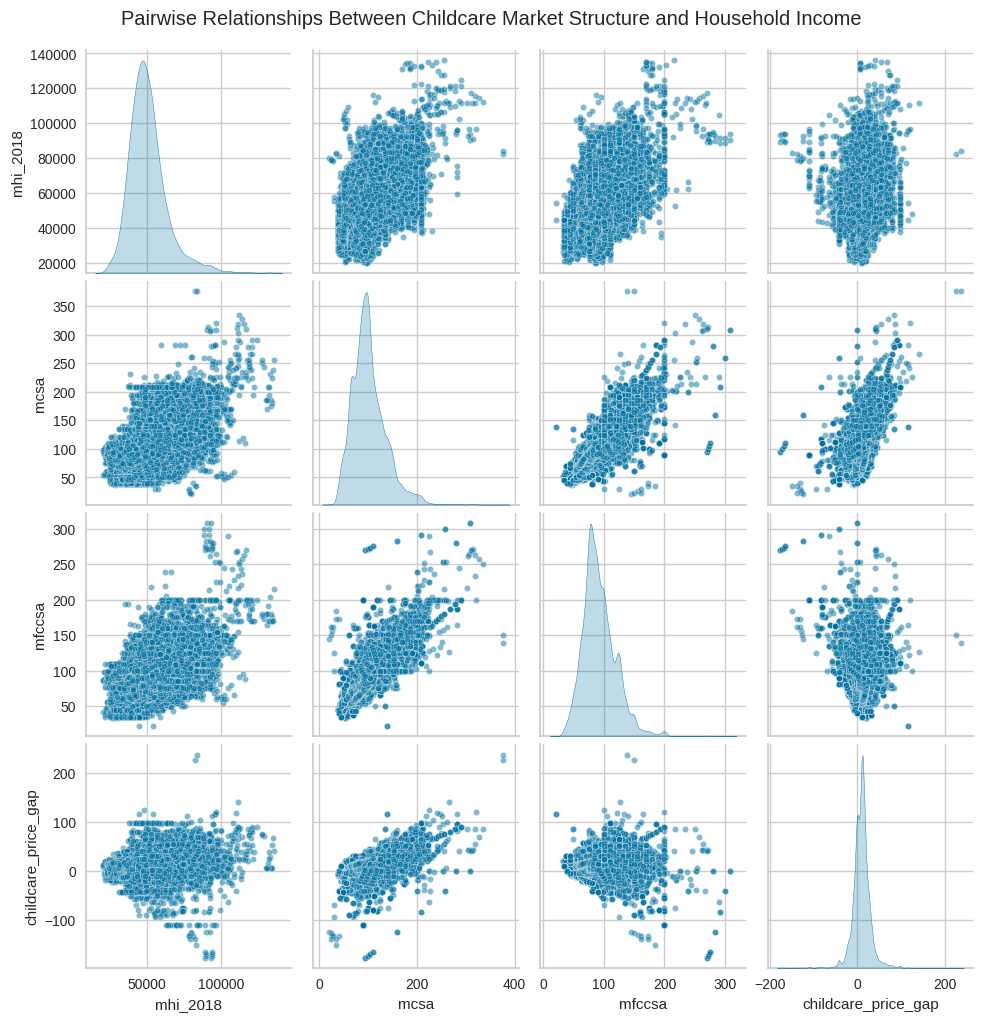

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

merged_df["childcare_price_gap"] = (
    merged_df["mcsa"] - merged_df["mfccsa"]
)

childcare_vars = [
    "mhi_2018",
    "mcsa",
    "mfccsa",
    "childcare_price_gap"
]

plot_df = merged_df[childcare_vars].dropna()

sns.pairplot(
    plot_df,
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20}
)

plt.suptitle(
    "Pairwise Relationships Between Childcare Market Structure and Household Income",
    y=1.02
)
plt.show()

Although median household income and childcare costs are both right-skewed, the relatively even distribution of the childcare price gap around zero indicates that childcare costs tend to move proportionally with earnings across counties. This consistency suggests that structural features of the childcare market limit large disparities between center-based and family childcare pricing.

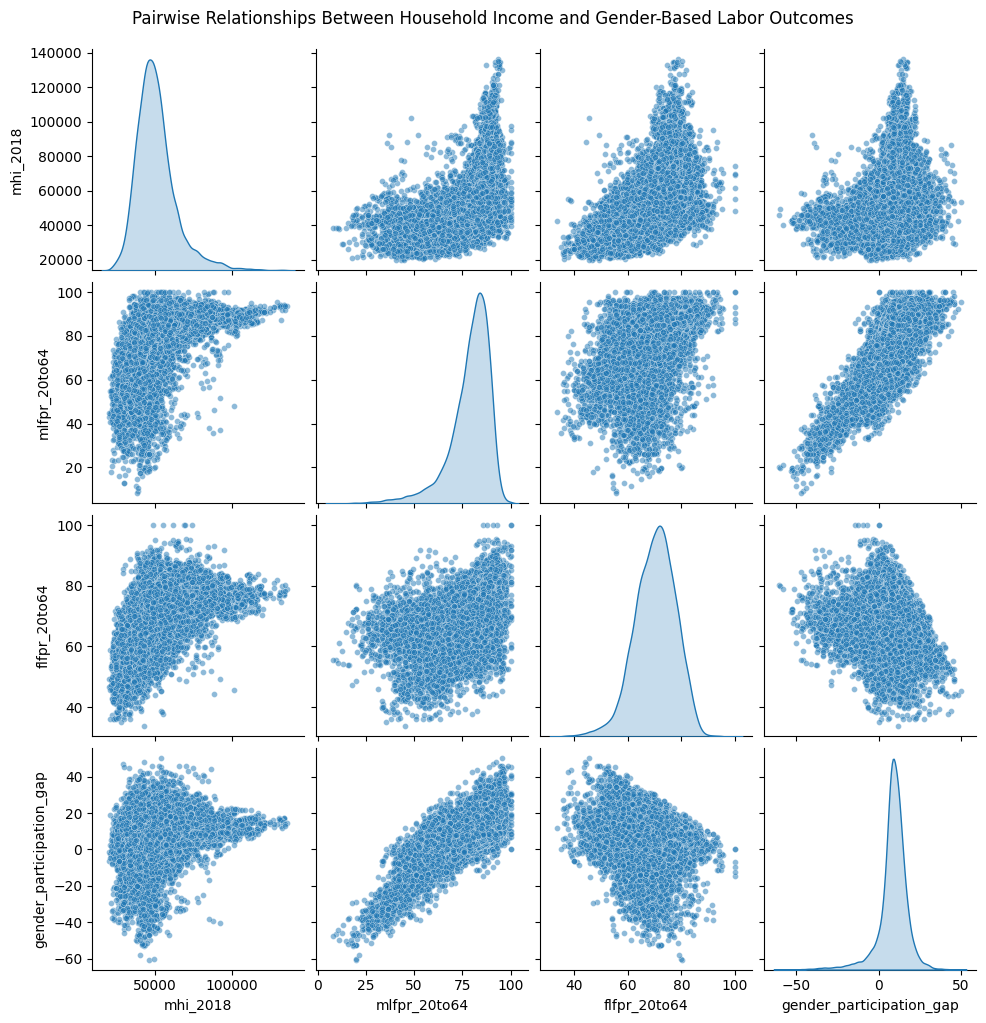

In [13]:
merged_df["gender_participation_gap"] = (
    merged_df["mlfpr_20to64"] - merged_df["flfpr_20to64"]
)

gender_vars = [
    "mhi_2018",
    "mlfpr_20to64",
    "flfpr_20to64",
    "gender_participation_gap"
]

gender_plot_df = merged_df[gender_vars].dropna()

sns.pairplot(
    gender_plot_df,
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 18}
)

plt.suptitle(
    "Pairwise Relationships Between Household Income and Gender-Based Labor Outcomes",
    y=1.02
)

plt.show()

The pairplot shows that median household income is concentrated in the lower-to-middle range across counties. While female labor force participation rates exhibit greater variability, male labor force participation rates are generally higher and more tightly distributed. Overall, the gender-based labor force participation gap is strongly centered near zero but remains predominantly positive, indicating that males consistently have higher participation rates across counties. Moreover, counties with higher female labor force participation tend to exhibit smaller gender participation gaps, suggesting that greater female workforce engagement is associated with more balanced labor force participation.

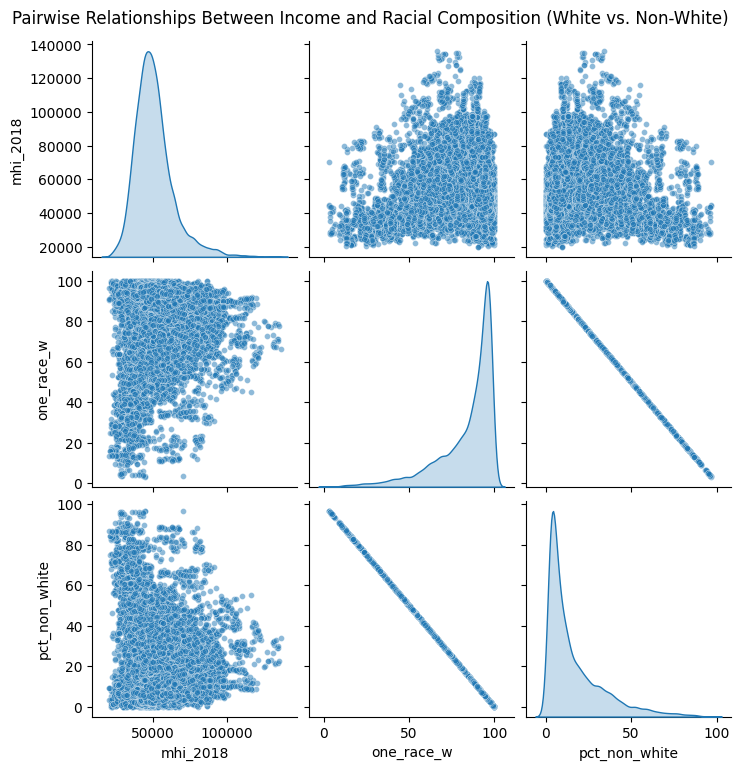

In [14]:
merged_df["pct_non_white"] = 100 - merged_df["one_race_w"]

race_vars = [
    "mhi_2018",
    "one_race_w",
    "pct_non_white"
]

race_plot_df = merged_df[race_vars].dropna()

sns.pairplot(
    race_plot_df,
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 18}
)

plt.suptitle(
    "Pairwise Relationships Between Income and Racial Composition (White vs. Non-White)",
    y=1.02
)

plt.show()

The pairplot shows a skewed distribution of median household income and highlights its relationship with racial composition. Counties with higher percentages of White residents tend to exhibit higher median household incomes, while counties with larger non-White populations are more concentrated at lower income levels. These patterns suggest a negative association between non-White population share and median household income at the county level.

# **Analysis and Experiments**

**Hierarchical Clustering**

*Do counties with higher proportions of racial and ethnic minority populations exhibit larger price gaps between center-based and family childcare?*

In [15]:
merged_df["pct_minority"] = (
    merged_df["one_race_b"] +
    merged_df["one_race_i"] +
    merged_df["one_race_a"] +
    merged_df["one_race_h"] +
    merged_df["one_race_other"] +
    merged_df["hispanic"]
)

merged_df["pct_white"] = merged_df["one_race_w"]

In [16]:
merged_df["race_total_check"] = merged_df["pct_white"] + merged_df["pct_minority"]

merged_df["race_total_check"].describe()

,race_total_check
count,34567.000000
mean,106.320372
std,13.199882
min,59.400000
25%,100.200000
50%,101.600000
75%,106.000000
max,198.800000


In [17]:
from sklearn.preprocessing import StandardScaler

merged_df["center_childcare"] = merged_df["mcsa"]
merged_df["family_childcare"] = merged_df["mfccsa"]

features = [
    "pct_white",
    "pct_minority",
    "center_childcare",
    "family_childcare",
    "childcare_price_gap"
]

cluster_df = merged_df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

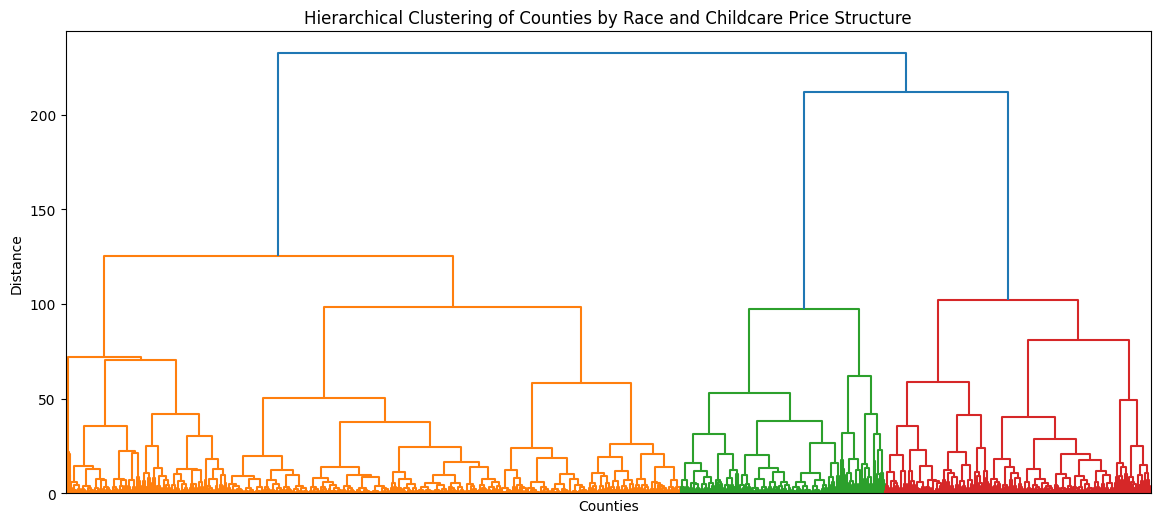

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, no_labels=True)
plt.title("Hierarchical Clustering of Counties by Race and Childcare Price Structure")
plt.xlabel("Counties")
plt.ylabel("Distance")
plt.show()

The dendrogram above shows three groupings (in three different colors), which represent the different county profiles.

In [21]:
from scipy.cluster.hierarchy import fcluster

merged_df.loc[cluster_df.index, "race_price_cluster"] = (
    fcluster(Z, t=4, criterion="maxclust")
)

merged_df

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,childcare_price_gap,pct_non_white,pct_minority,pct_white,race_total_check,center_childcare,family_childcare,annual_center_childcare_cost,childcare_affordability,race_price_cluster
0,01001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,-0.48,21.1,21.0,78.9,99.9,80.92,81.40,4207.84,0.071975,2.0
1,01001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,-2.26,20.9,21.6,79.1,100.7,83.42,85.68,4337.84,0.072043,2.0
2,01001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,-4.04,20.9,21.8,79.1,100.9,85.92,89.96,4467.84,0.072323,2.0
3,01001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,-5.82,21.1,21.9,78.9,100.8,88.43,94.25,4598.36,0.076174,2.0
4,01001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,-7.60,21.1,22.0,78.9,100.9,90.93,98.53,4728.36,0.079938,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34562,56045,2014,3.60,5.36,2.28,2.4,4.8,0.6,75.9,74.8,...,-21.80,6.6,8.7,93.4,102.1,91.14,112.94,4739.28,0.082919,1.0
34563,56045,2015,5.16,7.86,3.16,4.2,7.6,1.6,73.2,82.0,...,-16.13,5.3,5.3,94.7,100.0,94.76,110.89,4927.52,0.080512,1.0
34564,56045,2016,3.61,4.67,2.79,3.4,4.5,2.6,69.7,68.1,...,-10.47,6.8,6.4,93.2,99.6,98.38,108.85,5115.76,0.087566,1.0
34565,56045,2017,2.24,2.64,1.95,2.3,2.8,2.0,71.4,63.6,...,-4.80,7.0,6.3,93.0,99.3,102.01,106.81,5304.52,0.086402,1.0


In [22]:
cluster_summary = (
    merged_df
    .groupby("race_price_cluster")
    .agg({
        "pct_white": "mean",
        "pct_minority": "mean",
        "childcare_price_gap": "mean",
        "center_childcare": "mean",
        "family_childcare": "mean"
    })
    .round(2)
)

cluster_summary

,pct_white,pct_minority,childcare_price_gap,center_childcare,family_childcare
race_price_cluster,,,,,
1.0,89.83,14.24,-16.78,94.99,111.77
2.0,91.74,10.04,6.28,83.96,77.67
3.0,86.52,20.32,30.07,151.66,121.58
4.0,66.14,50.58,11.90,95.56,83.66


The cluster summary above shows that four general clusters formed with different structural profiles. In Clusters 1 and 2, predominantly White counties were identified where childcare costs reflect lower affordability pressures, with smaller or negative price gaps between center-based and family childcare. In contrast, Clusters 3 and 4 include counties with higher representation of racial and ethnic minority populations, where patterns show larger childcare affordability disparities.

**K-Means**

*How does gender-based participation vary across counties with different levels of childcare affordability, and what does this reveal about gendered economic vulnerability?*

In [25]:
merged_df["annual_center_childcare_cost"] = merged_df["mcsa"] * 52

merged_df["childcare_affordability"] = (
    merged_df["annual_center_childcare_cost"] /
    merged_df["mhi_2018"]
)

features = [
    "childcare_affordability",
    "gender_participation_gap"
]

X = merged_df[features].dropna()

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=features,
    index=X.index
)

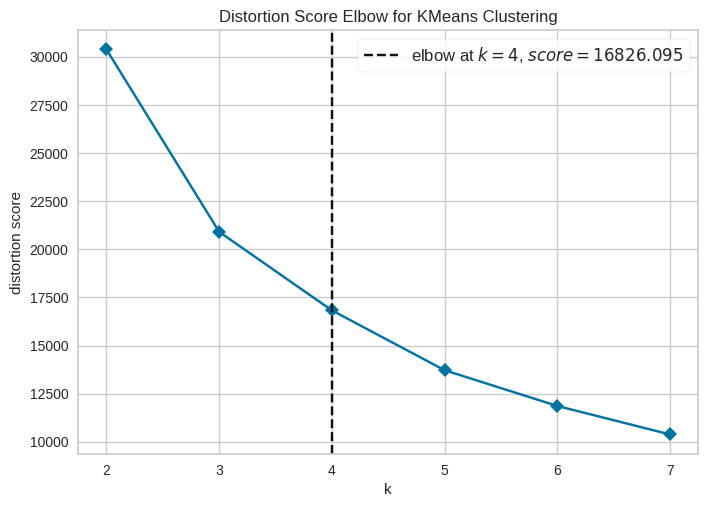

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [52]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42, n_init=10)

visualizer = KElbowVisualizer(
    model,
    k=(2, 8),
    metric="distortion",
    timings=False
)

visualizer.fit(X_scaled)
visualizer.show()

This elbow plot shows that k = 4 is a good balance between model fit and interpretability. Moving beyond this line the the rate of improvement begins to level off so our k means can focus on using values equal to or less than 4 to build clusters and run analysis.

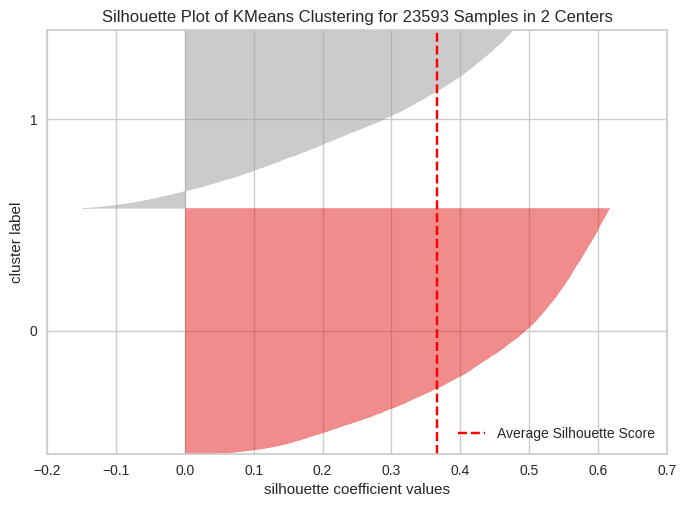

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23593 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [27]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer

k = 2

kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)

visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)
visualizer.show()

Average silhouette is around 0.38, with two very broad clusters that does not allow for deeper analysis.

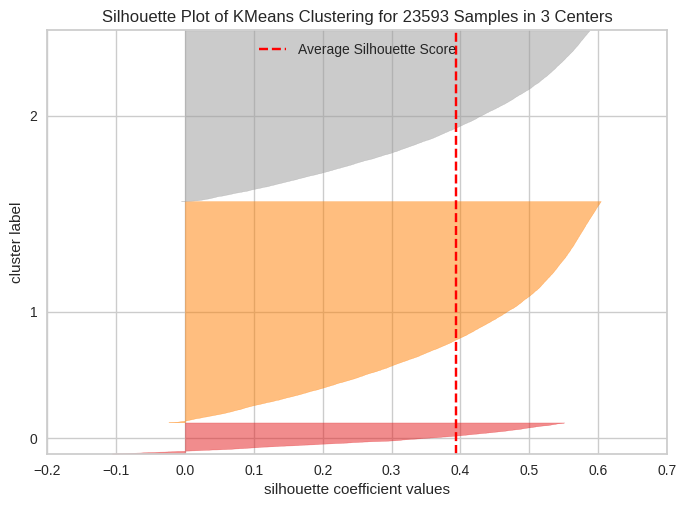

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23593 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [28]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer

k = 3

kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)

visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)
visualizer.show()

The silhouette value is the highest at k = 3, with an average silhouette score of ~0.4. This suggests that the clusters are reasonably well separated and that points are generally well matched to their assigned clusters. While the separation is not perfect, due to some points near the zero value, using three clusters overall appears to be a reasonable choice.

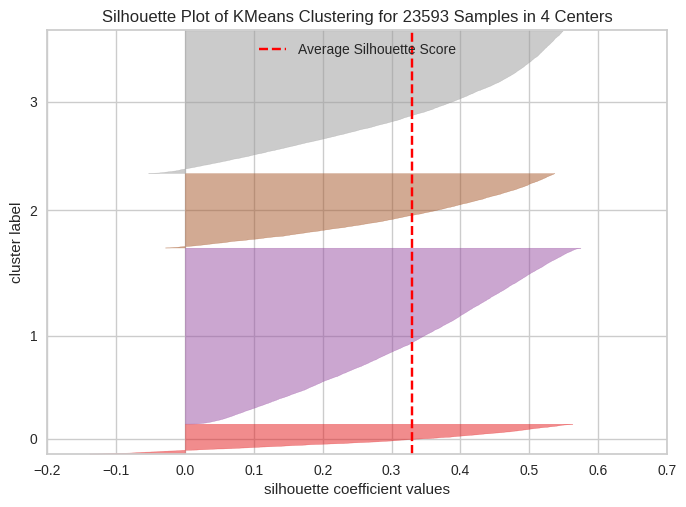

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23593 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [29]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer

k = 4

kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)

visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)
visualizer.show()

Too many fragments and outliers which yield noise and findings could be misinterpreted.

In [30]:
from sklearn.cluster import KMeans

final_k = 3

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

merged_df.loc[X_scaled.index, "cluster"] = kmeans.fit_predict(X_scaled)

In [34]:
cluster_summary = (
    merged_df
    .groupby("cluster")[[
        "childcare_affordability",
        "gender_participation_gap"
    ]]
    .mean()
)

cluster_summary

,childcare_affordability,gender_participation_gap
cluster,,
0.0,0.105897,-14.202870
1.0,0.083914,12.053341
2.0,0.135980,8.365162


The table above suggest cluster results that childcare affordability and gender participation gaps interact in non-uniform ways across counties. Although the less affordable counties tend to display male-dominated labor force participation, more affordable childcare does not necessarily correspond to gender parity, indicating that other underlysing structural labor factors may also play a role.

# **Previous EDA (M1)**

## **Gender Earning Gaps**

<Axes: >

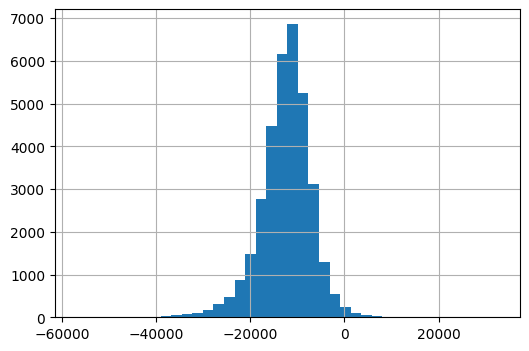

In [ ]:
merged_df['earnings_gap'] = merged_df['fme_2018'] - merged_df['mme_2018']
merged_df['earnings_gap'].hist(bins=40, figsize=(6,4))

There's an inequality in earnings distribution, with women earning less than men since the distribution is not centered at zero but towards large negative values.

## **Labor Fore Comparison**

<Axes: >

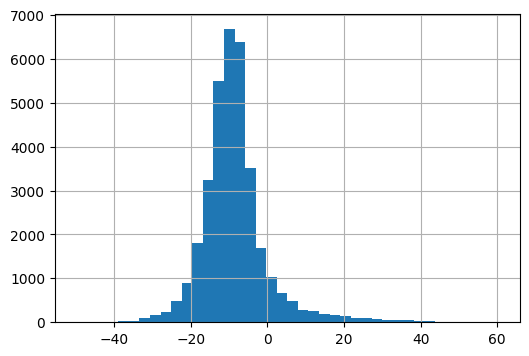

In [ ]:
merged_df['lfp_gap'] = merged_df['flfpr_20to64'] - merged_df['mlfpr_20to64']
merged_df['lfp_gap'].hist(bins=40, figsize=(6,4))

,lfp_child_gap
count,34567.000000
mean,-1.264716
std,10.052044
min,-77.000000
25%,-6.500000
50%,-1.500000
75%,4.100000
max,54.500000


**Labor force participation of the female population ages 20–64, ages 20–64 with children under 6, and ages 20–64 with children ages 6–17**

<Axes: >

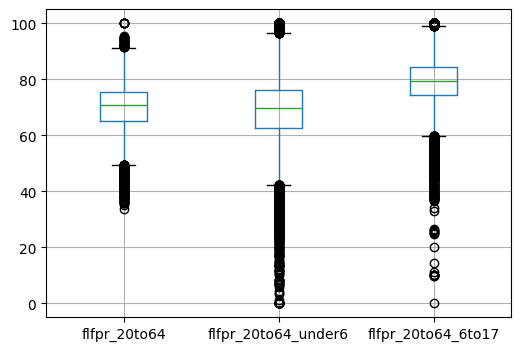

In [ ]:
merged_df[
    ['flfpr_20to64', 'flfpr_20to64_under6', 'flfpr_20to64_6to17']
].boxplot(figsize=(6,4))


The boxplots above indicate that from the three attributes, women ages 20-64 with children under 6 have the most outliers where there is very weak or no participation from them in the workforce.

## **Racial Demographics**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


demo_cols = [
    'one_race_w',
    'one_race_b',
    'one_race_i',
    'one_race_a',
    'one_race_h',
    'one_race_other',
    'two_races',
    'hispanic'
]


demo_means = merged_df[demo_cols].mean()

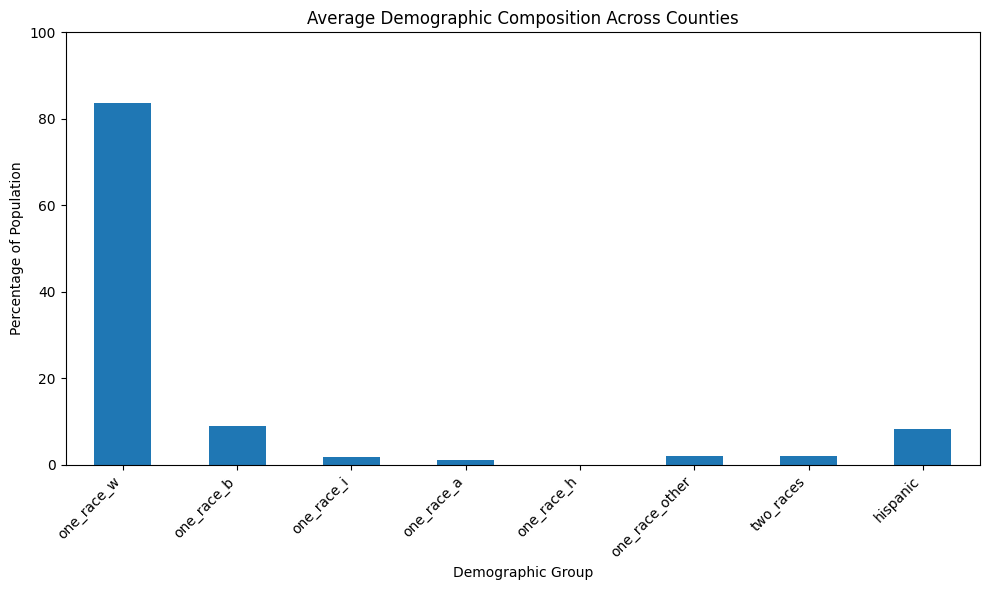

In [ ]:
plt.figure(figsize=(10,6))
demo_means.plot(kind='bar')

plt.title('Average Demographic Composition Across Counties')
plt.ylabel('Percentage of Population')
plt.xlabel('Demographic Group')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## **Houeshold Composition**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

household_cols = [
    'h_under6_both_work',
    'h_under6_f_work',
    'h_under6_m_work',
    'h_under6_single_m',
    'h_6to17_both_work',
    'h_6to17_fwork',
    'h_6to17_mwork',
    'h_6to17_single_m'
]

household_totals = merged_df[household_cols].sum()

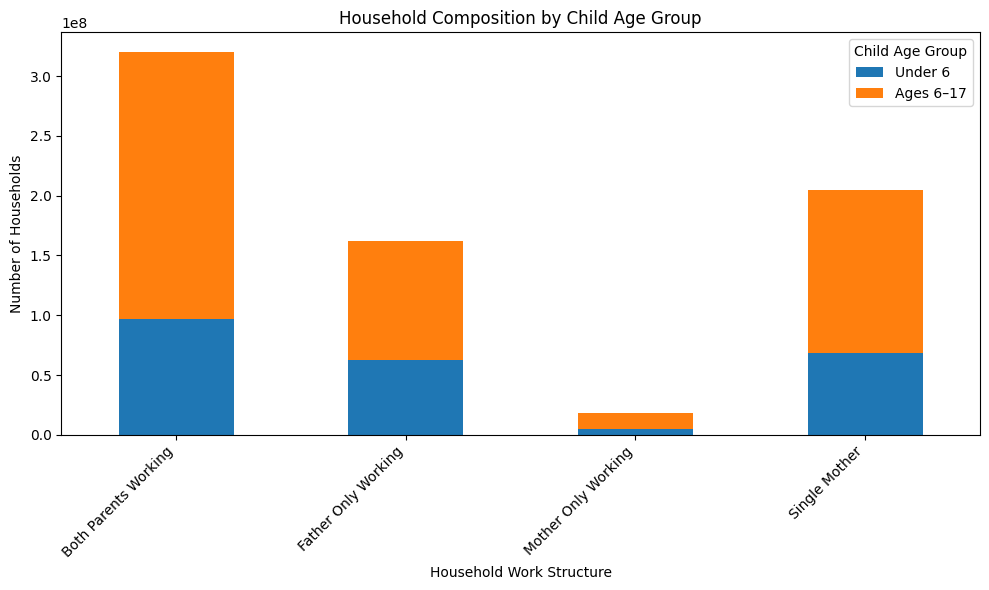

In [ ]:
household_df = pd.DataFrame({
    'Under 6': [
        household_totals['h_under6_both_work'],
        household_totals['h_under6_f_work'],
        household_totals['h_under6_m_work'],
        household_totals['h_under6_single_m']
    ],
    'Ages 6–17': [
        household_totals['h_6to17_both_work'],
        household_totals['h_6to17_fwork'],
        household_totals['h_6to17_mwork'],
        household_totals['h_6to17_single_m']
    ]
}, index=[
    'Both Parents Working',
    'Father Only Working',
    'Mother Only Working',
    'Single Mother'
])

household_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Household Composition by Child Age Group')
plt.ylabel('Number of Households')
plt.xlabel('Household Work Structure')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Child Age Group')
plt.tight_layout()
plt.show()


Households with children under six are less likely to have both parents working and more likely to rely on single-earner or single-mother arrangements, while households with children aged 6–17 are predominantly dual-earner, reflecting reduced childcare constraints as children reach school age. It is also important to note that father-only working households far outnumber mother-only working households in both age groups, highlighting persistent gender asymmetries in caregiving and labor force participation.

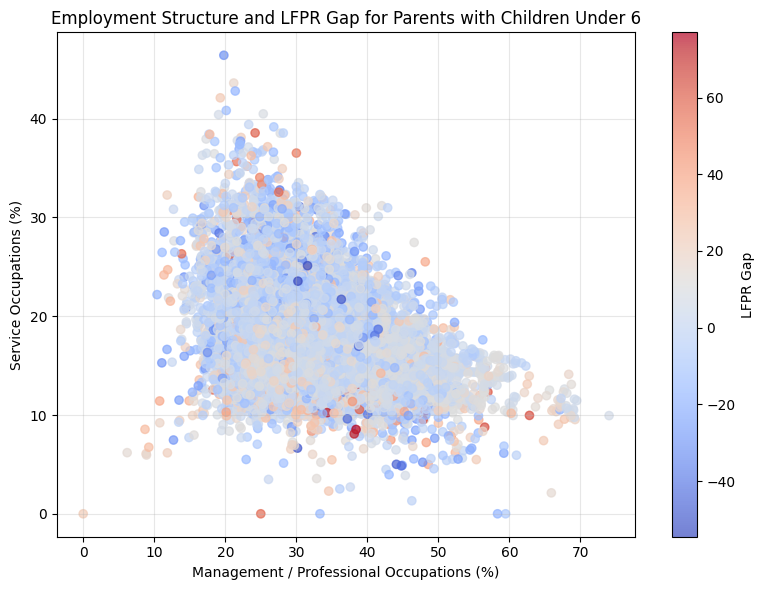

In [ ]:
import matplotlib.pyplot as plt

# Create LFPR gap
merged_df['lfpr_gap'] = (
    merged_df['flfpr_20to64'] - merged_df['flfpr_20to64_under6']
)

plt.figure(figsize=(8,6))

sc = plt.scatter(
    merged_df['emp_m'],
    merged_df['emp_service'],
    c=merged_df['lfpr_gap'],
    cmap = 'coolwarm',
    alpha=0.7
)

plt.xlabel('Management / Professional Occupations (%)')
plt.ylabel('Service Occupations (%)')
plt.title('Employment Structure and LFPR Gap for Parents with Children Under 6')

plt.colorbar(sc, label='LFPR Gap')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The plot above depicts the Labor Force Participation Rate Gap, where warmer colors indicate a larger gap and cooler colors showing a smaller gap. We can see that there is a greater constrain and larger LFPR gap for parents to stay in the larbor force in service occupations. In contrast, counties with a greater share of management and professional occupations generally show smaller participation gaps, suggesting that job flexibility, wages, and workplace supports may mitigate childcare-related labor market penalties.

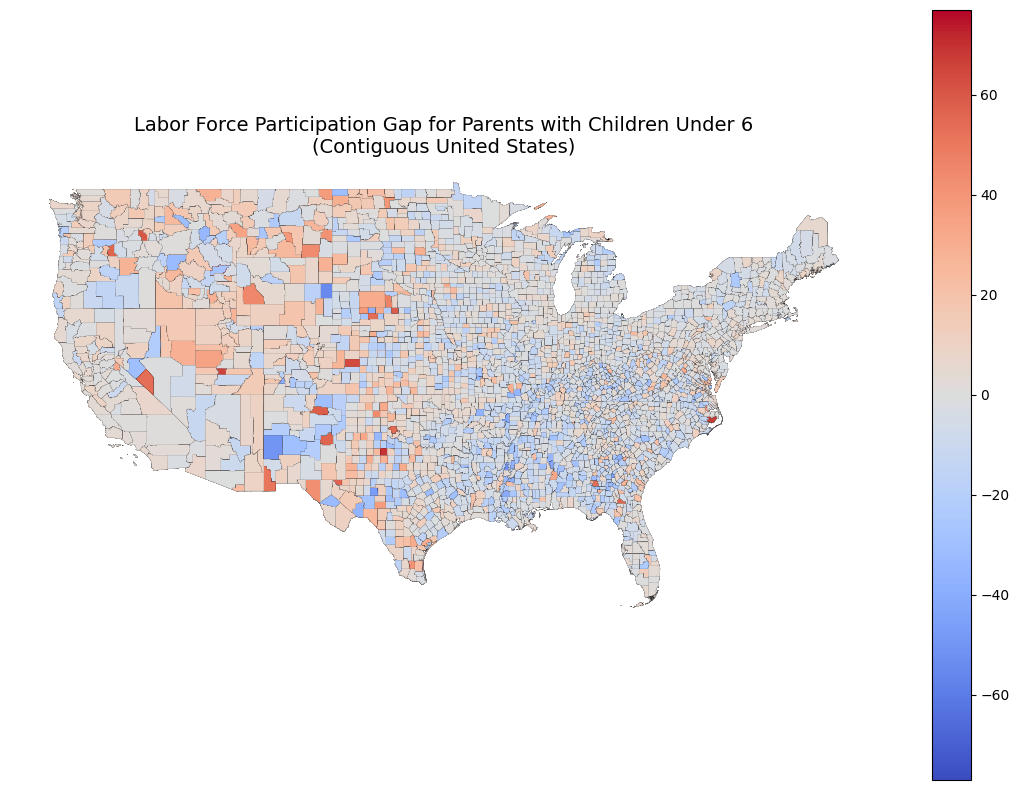

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

merged_df['lfpr_gap'] = (
    merged_df['flfpr_20to64'] - merged_df['flfpr_20to64_under6']
)

merged_df['county_fips_code'] = (
    merged_df['county_fips_code'].astype(str).str.zfill(5)
)


counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip"
)

counties['GEOID'] = counties['GEOID'].astype(str)


map_df = counties.merge(
    merged_df,
    left_on='GEOID',
    right_on='county_fips_code',
    how='left'
)


contiguous = map_df[
    ~map_df['STATEFP'].isin(['02', '15', '60', '66', '69', '72', '78'])
]


fig, ax = plt.subplots(1, 1, figsize=(14,10))


vmax = max(
    abs(contiguous['lfpr_gap'].min()),
    abs(contiguous['lfpr_gap'].max())
)

contiguous.plot(
    column='lfpr_gap',
    cmap='coolwarm',
    vmin=-vmax,
    vmax=vmax,
    linewidth=0.05,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title(
    'Labor Force Participation Gap for Parents with Children Under 6\n(Contiguous United States)',
    fontsize=14
)
ax.axis('off')

plt.show()

The map reveals regional clustering in labor force participation gaps for parents with children under six. Larger gaps are more prevalent across parts of the Midwest and South, while smaller gaps are more common in Northern regions, along the West Coast, and in major metropolitan areas. This spatial pattern suggests that local labor market conditions and institutional supports play an important role in shaping parental labor force participation outcomes.

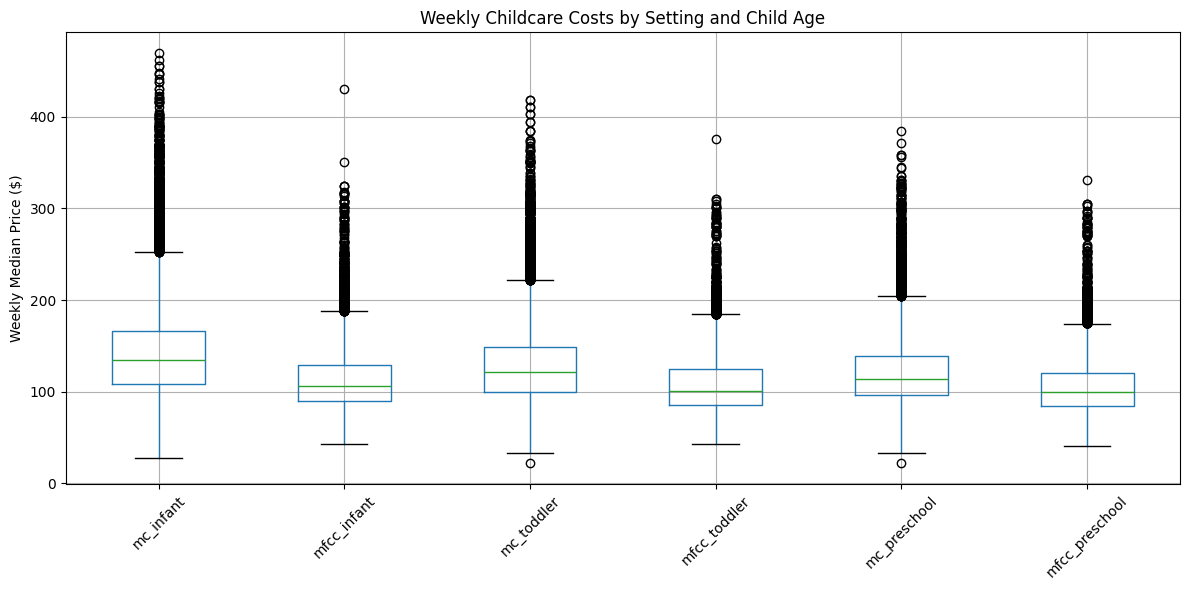

In [ ]:
import matplotlib.pyplot as plt

cols = [
    'mc_infant', 'mfcc_infant',
    'mc_toddler', 'mfcc_toddler',
    'mc_preschool', 'mfcc_preschool'
]

merged_df[cols].boxplot(figsize=(12,6), rot=45)

plt.title('Weekly Childcare Costs by Setting and Child Age')
plt.ylabel('Weekly Median Price ($)')
plt.tight_layout()
plt.show()


The boxplots above are comparing the weekly childcare cost distribution. The presence of high outliers indicates that childcare costs can be exceptionally high in certain counties(metropolitan places), particularly for infants and center-based care. While most counties fall within a more moderate cost range, this variation highlights substantial geographic inequality in childcare affordability, which may contribute to uneven labor force participation outcomes among parents with young children.